# Pump Sensor Data Analysis

The dataset contains continuous readings from 51 industrial pump sensors timestamped at ~1-minute intervals. The goal is to predict `machine_status`: NORMAL, BROKEN, or RECOVERING.

**Sections:**
1. Imports
2. Load & Clean Data
3. Exploratory Data Analysis
4. Feature Selection
5. Train-Test Split
6. Handling Class Imbalance with SMOTE
7. Identifying the Top 3 Predictors of Failure
8. Model Training and Comparison
9. Evaluation
10. Saving the Best Model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score, average_precision_score,
)

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed. Run: pip install imbalanced-learn')
    IMBLEARN_AVAILABLE = False

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    XGBOOST_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

LABEL_MAP    = {'NORMAL': 0, 'BROKEN': 1, 'RECOVERING': 2}
INV_MAP      = {v: k for k, v in LABEL_MAP.items()}
TARGET_NAMES = ['NORMAL', 'BROKEN', 'RECOVERING']
COLORS       = {'NORMAL': 'steelblue', 'BROKEN': 'crimson', 'RECOVERING': 'darkorange'}
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load & Clean Data

In [2]:
df = pd.read_csv('sensor.csv')

# The first column is the original CSV row index
df = df.rename(columns={'Unnamed: 0': 'row_id'})
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Inspect sensor_15 before removing it
s15_valid   = df['sensor_15'].count()
s15_missing = df['sensor_15'].isnull().sum()
print(f'\nsensor_15  valid readings   : {s15_valid}')
print(f'sensor_15  missing readings : {s15_missing:,}  ({s15_missing / len(df):.1%})')
print('sensor_15 is completely empty -- dropping it.')

# Drop uninformative columns
df = df.drop(['row_id', 'sensor_15'], axis=1)

# Forward fill (time-safe), then backward fill for leading NaNs
df = df.ffill().bfill()

print(f'\nFinal shape   : {df.shape}')
print(f'Date range    : {df["timestamp"].min().date()}  to  {df["timestamp"].max().date()}')
print(f'Remaining NaNs: {df.isnull().sum().sum()}')
print('\nClass distribution:')
vc = df['machine_status'].value_counts()
for status, count in vc.items():
    print(f'  {status:<12}  {count:>7,}  ({count / len(df):.2%})')

Loaded: 220,320 rows, 55 columns

sensor_15  valid readings   : 0
sensor_15  missing readings : 220,320  (100.0%)
sensor_15 is completely empty -- dropping it.

Final shape   : (220320, 53)
Date range    : 2018-04-01  to  2018-08-31
Remaining NaNs: 0

Class distribution:
  NORMAL        205,836  (93.43%)
  RECOVERING     14,477  (6.57%)
  BROKEN              7  (0.00%)


## 3. Exploratory Data Analysis

### 3.1 sensor_00 over time vs machine_status

Plotting one sensor against the machine status labels gives an intuitive view of what failure looks like in the data.

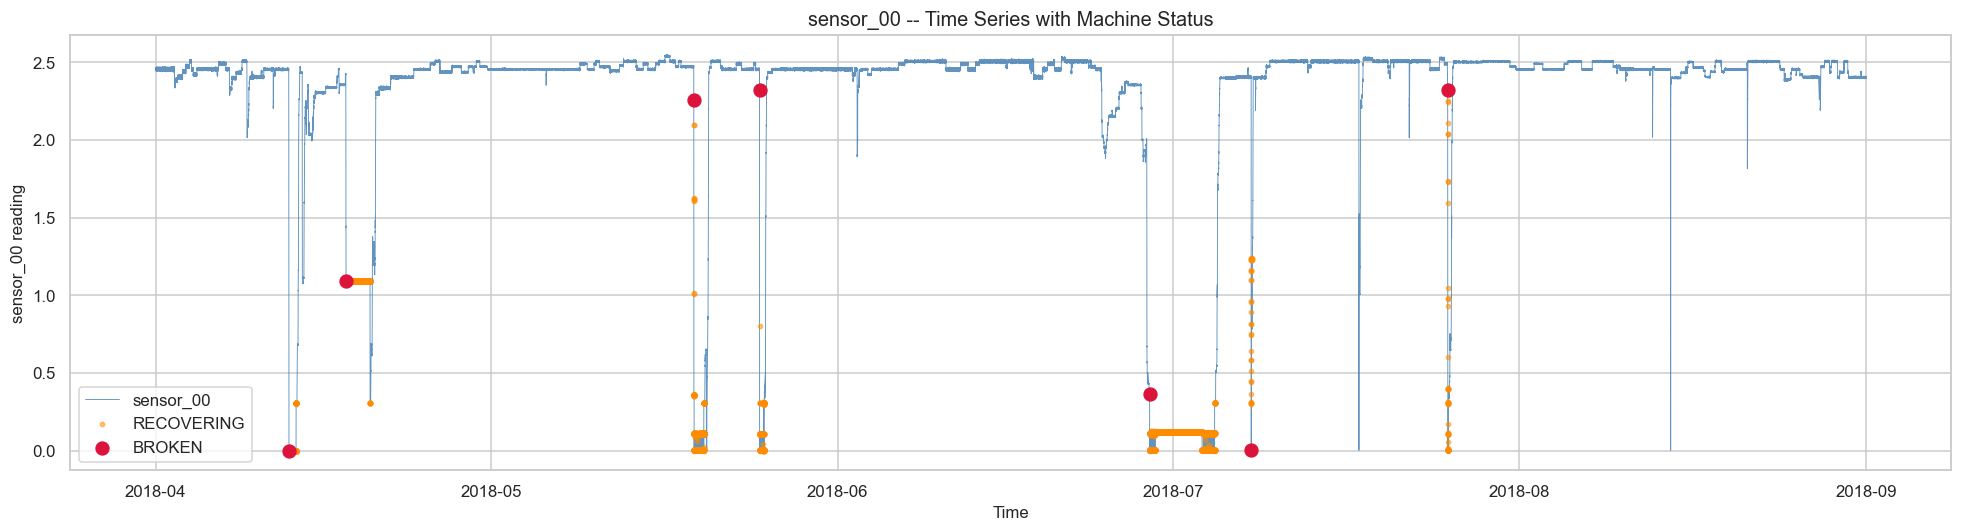

In [3]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['timestamp'], df['sensor_00'], color=COLORS['NORMAL'],
        linewidth=0.6, alpha=0.85, label='sensor_00')

for status in ['RECOVERING', 'BROKEN']:
    subset = df[df['machine_status'] == status]
    ax.scatter(subset['timestamp'], subset['sensor_00'],
               color=COLORS[status], label=status,
               s=(70 if status == 'BROKEN' else 8),
               zorder=(6 if status == 'BROKEN' else 4),
               alpha=(1.0 if status == 'BROKEN' else 0.5))

ax.set_title('sensor_00 -- Time Series with Machine Status')
ax.set_xlabel('Time')
ax.set_ylabel('sensor_00 reading')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** During normal operation `sensor_00` holds a steady band. A sharp drop appears immediately before each BROKEN event -- the sensor signal deteriorates *before* the failure label appears, making it a useful early warning indicator. During RECOVERING the reading stays suppressed and volatile before returning to the normal range.

### 3.2 Class Imbalance

Before modelling, the class distribution needs a close look.

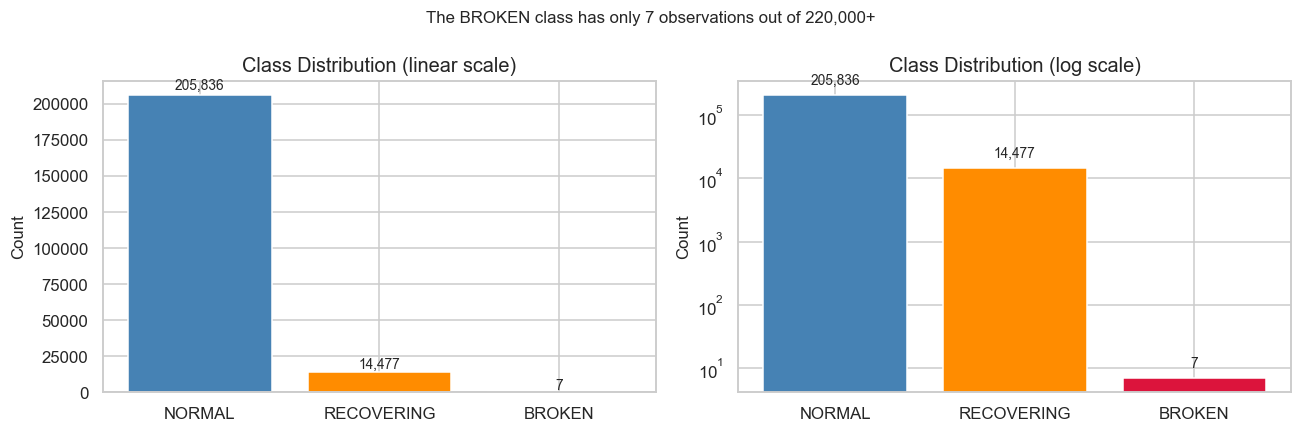

NORMAL:BROKEN ratio = 205,836 : 7  (~29,405:1)


In [4]:
vc = df['machine_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_, scale in zip(axes, ['linear', 'log']):
    bars = ax_.bar(vc.index, vc.values,
                   color=[COLORS[s] for s in vc.index], edgecolor='white')
    ax_.set_title(f'Class Distribution ({scale} scale)')
    ax_.set_ylabel('Count')
    if scale == 'log':
        ax_.set_yscale('log')
    for bar, val in zip(bars, vc.values):
        ax_.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * (1.3 if scale == 'log' else 1.01),
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('The BROKEN class has only 7 observations out of 220,000+', fontsize=11)
plt.tight_layout()
plt.show()

print(f'NORMAL:BROKEN ratio = {vc["NORMAL"]:,} : {vc["BROKEN"]}  (~{vc["NORMAL"] // vc["BROKEN"]:,}:1)')

This is a severe imbalance. NORMAL accounts for over 93% of rows, and BROKEN appears only 7 times. A model that predicts NORMAL for every row scores 93.4% accuracy while missing every single failure. Accuracy is the wrong metric here -- this will be addressed in Section 6.

### 3.3 Correlation Heatmap

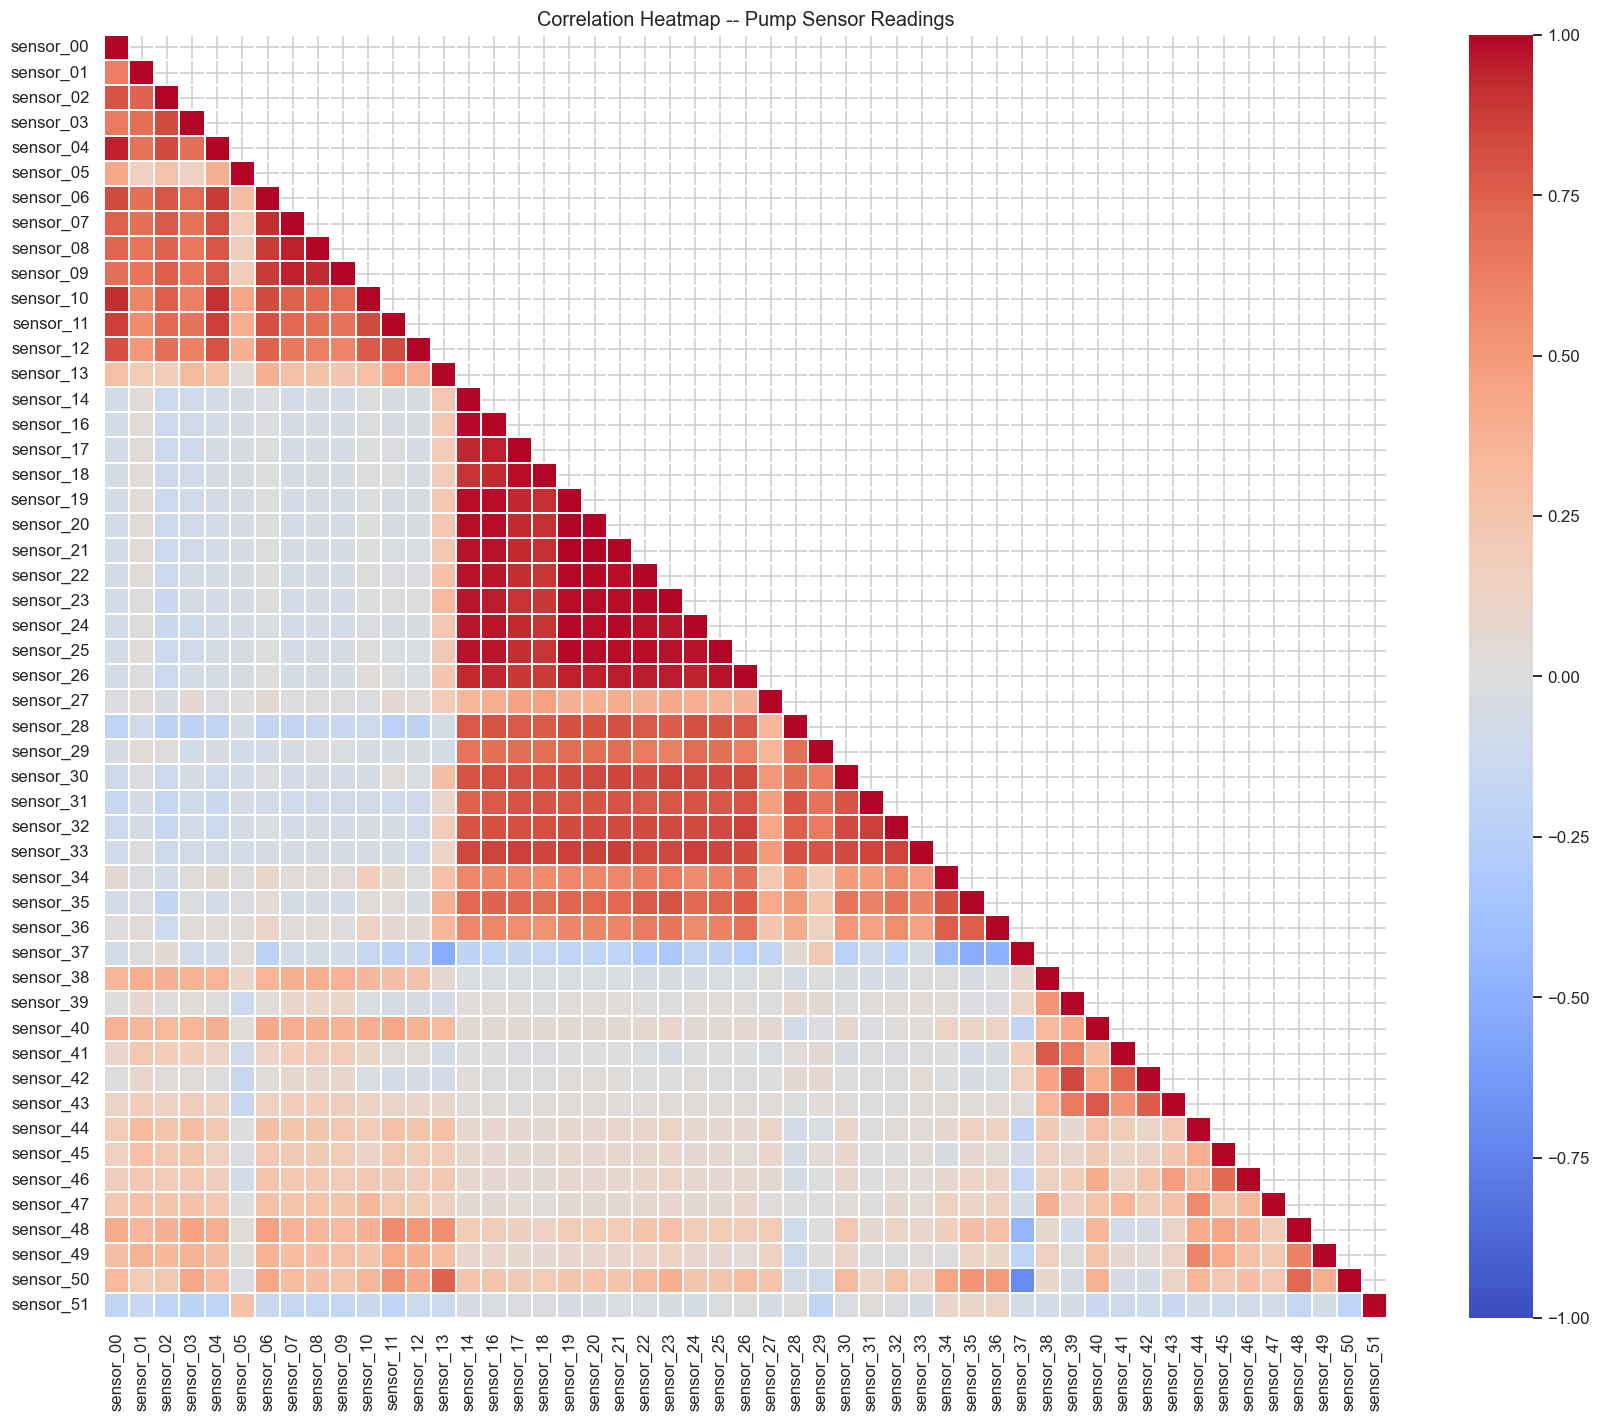

In [5]:
corr = df.drop(['timestamp', 'machine_status'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            cbar=True, square=True, linewidths=0.2, ax=ax)
ax.set_title('Correlation Heatmap -- Pump Sensor Readings')
plt.tight_layout()
plt.show()

Several sensor clusters are strongly correlated, capturing the same underlying physical signal. Tree-based models (Random Forest, XGBoost) handle correlated features naturally, making them a better primary choice than Logistic Regression for this data.

## 4. Feature Selection

After dropping `row_id`, `timestamp`, `sensor_15` (100% null), and the target column, the model uses the **51 raw sensor readings** directly. No additional feature engineering is applied -- the raw signals contain sufficient discriminative information, and keeping the feature space compact avoids overfitting given the very limited number of failure examples.

In [6]:
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

print(f'Sensor features: {len(sensor_cols)}')
print(', '.join(sensor_cols))

Sensor features: 51
sensor_00, sensor_01, sensor_02, sensor_03, sensor_04, sensor_05, sensor_06, sensor_07, sensor_08, sensor_09, sensor_10, sensor_11, sensor_12, sensor_13, sensor_14, sensor_16, sensor_17, sensor_18, sensor_19, sensor_20, sensor_21, sensor_22, sensor_23, sensor_24, sensor_25, sensor_26, sensor_27, sensor_28, sensor_29, sensor_30, sensor_31, sensor_32, sensor_33, sensor_34, sensor_35, sensor_36, sensor_37, sensor_38, sensor_39, sensor_40, sensor_41, sensor_42, sensor_43, sensor_44, sensor_45, sensor_46, sensor_47, sensor_48, sensor_49, sensor_50, sensor_51


## 5. Train-Test Split

For time series the split must be chronological. Shuffling rows at random allows future data to leak into the training set, which inflates evaluation metrics without reflecting real-world performance. The first 80% of the timeline is used for training; the last 20% is held out for testing.

In [7]:
X = df[sensor_cols]
y = df['machine_status'].map(LABEL_MAP)

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

cutoff = df['timestamp'].iloc[split_idx].date()
print(f'Training set  : {X_train.shape[0]:,} rows  ({X_train.shape[1]} features)  up to {cutoff}')
print(f'Test set      : {X_test.shape[0]:,} rows')
print(f'\nClass distribution in training:')
print(y_train.map(INV_MAP).value_counts().to_string())
print(f'\nClass distribution in test:')
print(y_test.map(INV_MAP).value_counts().to_string())

Training set  : 176,256 rows  (51 features)  up to 2018-08-01
Test set      : 44,064 rows

Class distribution in training:
machine_status
NORMAL        161772
RECOVERING     14477
BROKEN             7

Class distribution in test:
machine_status
NORMAL    44064


## 6. Handling the Class Imbalance

With only 7 BROKEN observations in the entire dataset, we need to address the imbalance before training. A few options:

**Class weights** -- adjusts the loss function to penalise minority misclassifications more heavily. Simple and data-safe, but the model still only sees the original handful of BROKEN examples to learn from.

**Random oversampling** -- duplicates minority rows. Fast, but memorisation risk.

**SMOTE** (Synthetic Minority Oversampling Technique) -- creates synthetic minority samples by interpolating between existing ones and their nearest neighbours. Gives the model varied examples rather than exact copies.

I applied SMOTE to the training data only, after the chronological split. The test set is untouched. One important detail: the default SMOTE strategy oversamples every minority class all the way up to the majority count (~165,000). With only 5-6 real BROKEN samples, that would generate 160k+ synthetic points from almost nothing -- basically noise. Instead, I oversample BROKEN only up to the RECOVERING count, which is a much more realistic target.

In [8]:
if IMBLEARN_AVAILABLE:
    min_class_count = int(pd.Series(y_train).value_counts().min())
    k = min(5, min_class_count - 1)

    n_recovering = int((y_train == 2).sum())
    broken_target = n_recovering  # match BROKEN to RECOVERING, not to NORMAL

    print(f'BROKEN in training    : {min_class_count} samples')
    print(f'RECOVERING in training: {n_recovering:,} samples')
    print(f'SMOTE target (BROKEN) : {broken_target:,}')
    print(f'k_neighbors           : {k}')

    smote = SMOTE(
        sampling_strategy={1: broken_target},
        random_state=RANDOM_STATE,
        k_neighbors=k,
    )
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print('\nClass distribution after SMOTE:')
    for label, cnt in pd.Series(y_train_res).map(INV_MAP).value_counts().sort_index().items():
        print(f'  {label:<12}  {cnt:>7,}')
    print(f'\nTraining rows: {len(y_train):,}  ->  {len(y_train_res):,}')
else:
    print('SMOTE unavailable. Models will use class_weight=balanced only.')
    X_train_res, y_train_res = X_train, y_train

BROKEN in training    : 7 samples
RECOVERING in training: 14,477 samples
SMOTE target (BROKEN) : 14,477
k_neighbors           : 5

Class distribution after SMOTE:
  BROKEN         14,477
  NORMAL        161,772
  RECOVERING     14,477

Training rows: 176,256  ->  190,726


## 7. Identifying the Top 3 Predictors of Failure

A Random Forest is trained on the SMOTE-balanced training set and Gini feature importances are extracted. Using the balanced set ensures the importances reflect failure patterns rather than just the NORMAL majority.

Top 3 sensors -- strongest predictors of failure:
  #1  sensor_04     importance = 0.1441
  #2  sensor_00     importance = 0.1212
  #3  sensor_10     importance = 0.0961


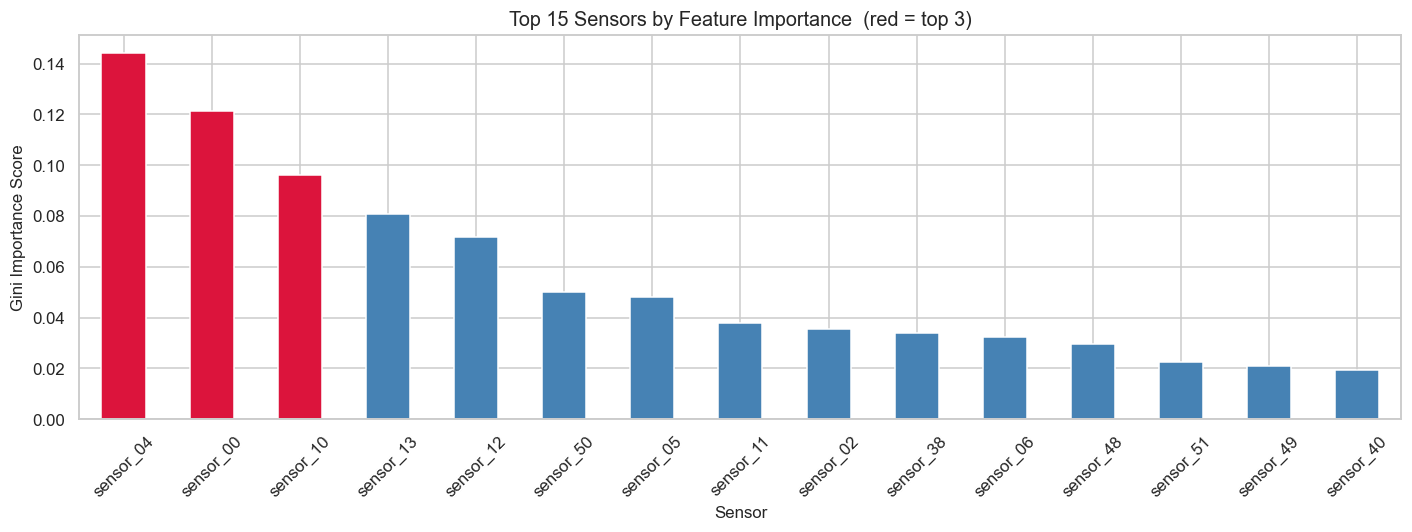

In [9]:
rf_fi = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf_fi.fit(X_train_res, y_train_res)

importances = pd.Series(rf_fi.feature_importances_, index=X_train_res.columns)
importances_sorted = importances.sort_values(ascending=False)
top_3  = importances_sorted.head(3)
top_15 = importances_sorted.head(15)

print('Top 3 sensors -- strongest predictors of failure:')
for rank, (sensor, score) in enumerate(top_3.items(), 1):
    print(f'  #{rank}  {sensor:<12}  importance = {score:.4f}')

colors_bar = ['crimson' if i < 3 else 'steelblue' for i in range(len(top_15))]
fig, ax = plt.subplots(figsize=(13, 5))
top_15.plot(kind='bar', color=colors_bar, edgecolor='white', ax=ax)
ax.set_title('Top 15 Sensors by Feature Importance  (red = top 3)')
ax.set_ylabel('Gini Importance Score')
ax.set_xlabel('Sensor')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Model Training and Comparison

Three classifiers are compared on the SMOTE-balanced training data. After SMOTE, BROKEN and RECOVERING are at similar counts but NORMAL still dominates roughly 7:1, so `class_weight='balanced'` is also applied to correct the residual imbalance.

| Model | Notes |
|---|---|
| Logistic Regression | Linear baseline; needs feature scaling via Pipeline |
| Random Forest | Handles non-linear and correlated features natively |
| XGBoost | Gradient boosting; often strongest on rare class detection |

In [10]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced',
            C=0.1, random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_features='sqrt', min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

if XGBOOST_AVAILABLE:
    n_majority = int((y_train_res == 0).sum())
    sw = np.where(
        y_train_res == 0, 1.0,
        np.where(y_train_res == 1,
                 n_majority / max(int((y_train_res == 1).sum()), 1),
                 n_majority / max(int((y_train_res == 2).sum()), 1))
    )
    xgb_model = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train_res, y_train_res)
    results[name] = {
        'model'  : model,
        'y_pred' : model.predict(X_test),
        'y_proba': model.predict_proba(X_test),
    }
    print('done.')

if XGBOOST_AVAILABLE:
    print('Training XGBoost...', end=' ', flush=True)
    xgb_model.fit(X_train_res, y_train_res, sample_weight=sw)
    results['XGBoost'] = {
        'model'  : xgb_model,
        'y_pred' : xgb_model.predict(X_test),
        'y_proba': xgb_model.predict_proba(X_test),
    }
    print('done.')

print('\nAll models trained.')

Training Logistic Regression... done.
Training Random Forest... done.
Training XGBoost... done.

All models trained.


## 9. Evaluation

### 9.1 Classification Reports

Note: BROKEN has no samples in the test set -- all 7 BROKEN rows fall in the first 80% of the timeline. BROKEN metrics will show 0, which reflects the data distribution, not model failure.

In [11]:
def safe_roc_auc(y_true, y_proba, class_labels):
    """Binary OvR AUC per class -- avoids the column-count mismatch in roc_auc_score."""
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    scores = []
    for idx in class_labels:
        if y_bin[:, idx].sum() == 0:
            continue
        scores.append(roc_auc_score(y_bin[:, idx], y_proba[:, idx]))
    return float(np.mean(scores)) if scores else float('nan')

present_classes = sorted(y_test.unique().tolist())
present_names   = [TARGET_NAMES[i] for i in present_classes]
if 1 not in present_classes:
    print(f'Test set contains: {present_names}  (BROKEN absent -- all in training period)\n')

for name, res in results.items():
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(
        y_test, res['y_pred'],
        target_names=TARGET_NAMES, labels=[0, 1, 2], zero_division=0,
    ))
    roc = safe_roc_auc(y_test, res['y_proba'], present_classes)
    rep = classification_report(
        y_test, res['y_pred'],
        target_names=TARGET_NAMES, labels=[0, 1, 2],
        zero_division=0, output_dict=True,
    )
    f1p = sum(rep[TARGET_NAMES[i]]['f1-score'] for i in present_classes) / len(present_classes)
    print(f'  F1 (present classes): {f1p:.4f}')
    print(f'  ROC-AUC (OvR)       : {roc:.4f}\n')

Test set contains: ['NORMAL']  (BROKEN absent -- all in training period)

  Logistic Regression
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     44064
      BROKEN       0.00      0.00      0.00         0
  RECOVERING       0.00      0.00      0.00         0

    accuracy                           1.00     44064
   macro avg       0.33      0.33      0.33     44064
weighted avg       1.00      1.00      1.00     44064

  F1 (present classes): 0.9996
  ROC-AUC (OvR)       : nan

  Random Forest
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     44064
      BROKEN       0.00      0.00      0.00         0
  RECOVERING       0.00      0.00      0.00         0

    accuracy                           1.00     44064
   macro avg       0.33      0.33      0.33     44064
weighted avg       1.00      1.00      1.00     44064

  F1 (present classes): 1.0000
  ROC-AUC (OvR)       : nan

  XGBo

### 9.2 Confusion Matrices

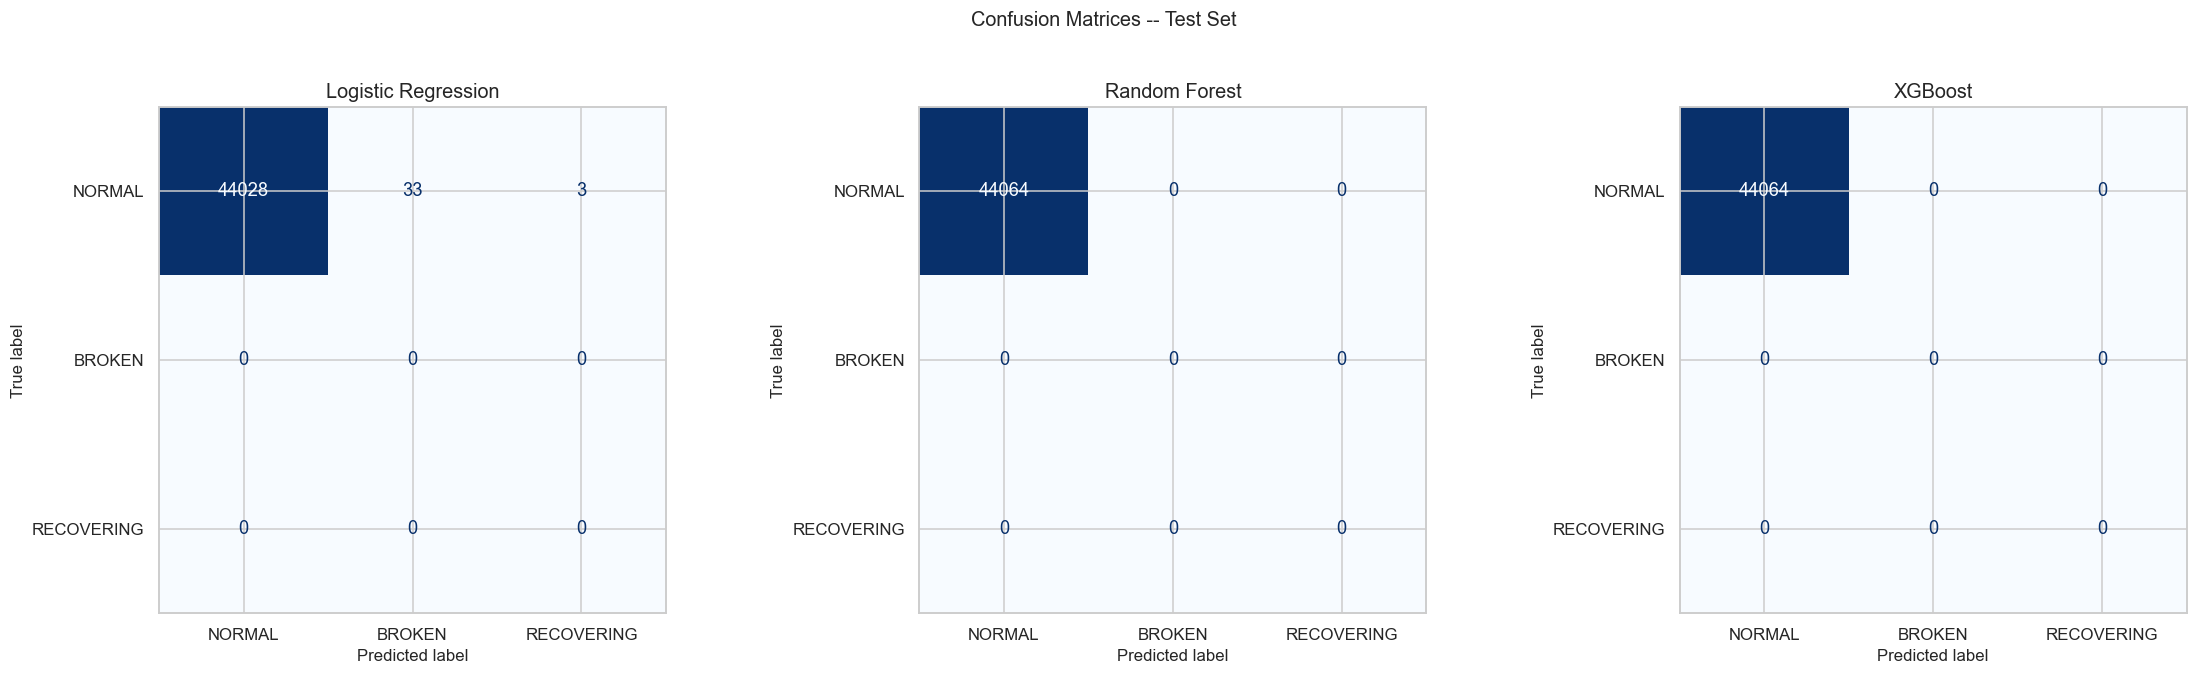

In [12]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for ax_, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=[0, 1, 2])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES).plot(
        cmap='Blues', ax=ax_, colorbar=False)
    ax_.set_title(name)

plt.suptitle('Confusion Matrices -- Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Precision-Recall Curves

With extreme class imbalance, ROC-AUC can look optimistic because it rewards correct rejection of the majority class. Precision-Recall curves focus on the minority classes and give a more honest picture of failure detection performance.

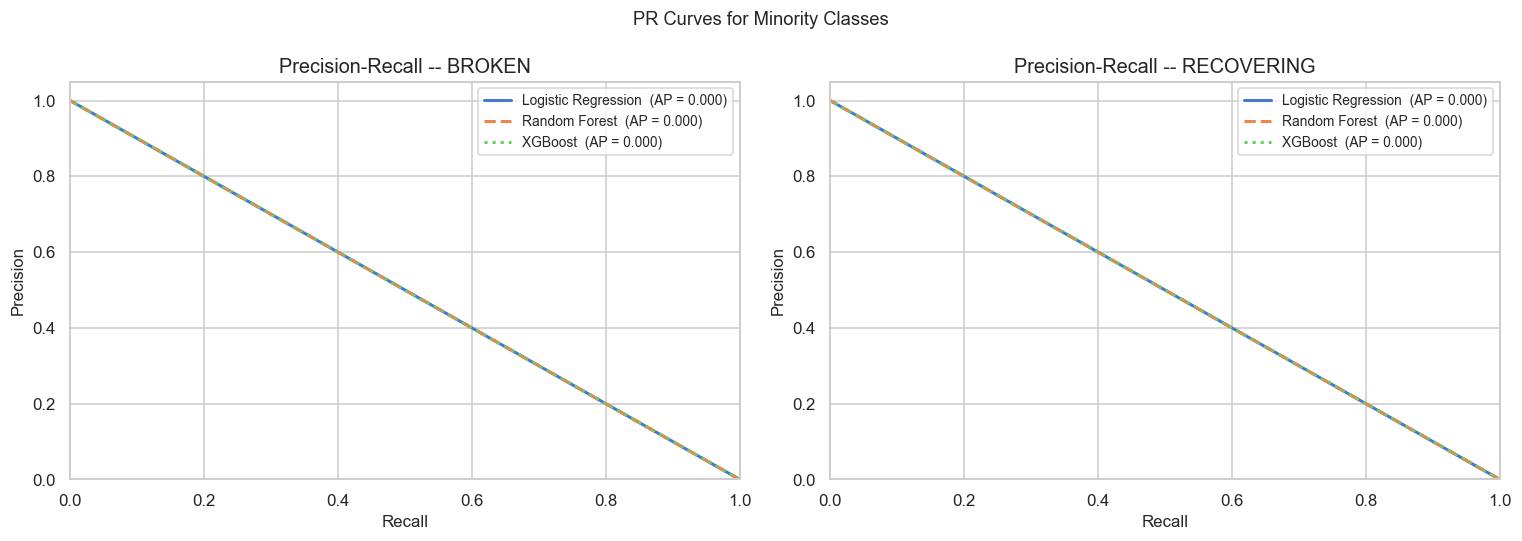

In [13]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_labels = {1: 'BROKEN', 2: 'RECOVERING'}
line_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_, cls_idx in zip(axes, [1, 2]):
    for (name, res), ls in zip(results.items(), line_styles):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, cls_idx], res['y_proba'][:, cls_idx])
        ap = average_precision_score(y_test_bin[:, cls_idx], res['y_proba'][:, cls_idx])
        ax_.plot(rec, prec, ls=ls, lw=2, label=f'{name}  (AP = {ap:.3f})')
    ax_.set_title(f'Precision-Recall -- {class_labels[cls_idx]}')
    ax_.set_xlabel('Recall')
    ax_.set_ylabel('Precision')
    ax_.set_xlim([0, 1])
    ax_.set_ylim([0, 1.05])
    ax_.legend(fontsize=9)

plt.suptitle('PR Curves for Minority Classes', fontsize=12)
plt.tight_layout()
plt.show()

### 9.4 Model Comparison Summary

In [14]:
def safe_roc_auc(y_true, y_proba, class_labels):
    """Binary OvR AUC per class -- avoids the column-count mismatch in roc_auc_score."""
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    scores = []
    for idx in class_labels:
        if y_bin[:, idx].sum() == 0:
            continue
        scores.append(roc_auc_score(y_bin[:, idx], y_proba[:, idx]))
    return float(np.mean(scores)) if scores else float('nan')

present_classes = sorted(y_test.unique().tolist())
present_names   = [TARGET_NAMES[i] for i in present_classes]
rows = []
for name, res in results.items():
    rep = classification_report(
        y_test, res['y_pred'],
        target_names=TARGET_NAMES, labels=[0, 1, 2],
        zero_division=0, output_dict=True,
    )
    roc = safe_roc_auc(y_test, res['y_proba'], present_classes)
    f1p = round(
        sum(rep[TARGET_NAMES[i]]['f1-score'] for i in present_classes) / len(present_classes), 4
    )
    rows.append({
        'Model'             : name,
        'F1 (present only)' : f1p,
        'Macro-F1 (3-class)': round(rep['macro avg']['f1-score'], 4),
        'Weighted-F1'       : round(rep['weighted avg']['f1-score'], 4),
        'ROC-AUC'           : round(roc, 4),
        'RECOVERING Recall' : round(rep.get('RECOVERING', {}).get('recall', 0), 4),
        'NORMAL Recall'     : round(rep.get('NORMAL',     {}).get('recall', 0), 4),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())
print('\n* F1 (present only): averages NORMAL and RECOVERING only')
print('* Macro-F1 (3-class): includes BROKEN recall=0 because BROKEN is absent from test')

best_model_name = summary['F1 (present only)'].idxmax()
print(f'\nBest model: {best_model_name}')

                     F1 (present only)  Macro-F1 (3-class)  Weighted-F1  ROC-AUC  RECOVERING Recall  NORMAL Recall
Model                                                                                                             
Logistic Regression             0.9996              0.3332       0.9996      NaN                0.0         0.9992
Random Forest                   1.0000              0.3333       1.0000      NaN                0.0         1.0000
XGBoost                         1.0000              0.3333       1.0000      NaN                0.0         1.0000

* F1 (present only): averages NORMAL and RECOVERING only
* Macro-F1 (3-class): includes BROKEN recall=0 because BROKEN is absent from test

Best model: Random Forest


## 10. Saving the Best Model

In [15]:
best_model = results[best_model_name]['model']
fname = f"best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
joblib.dump(best_model, fname)
print(f'Saved: {fname}')

# Reload check
loaded = joblib.load(fname)
sample = loaded.predict(X_test.iloc[:5])
print('Sanity check (first 5 predictions):', [INV_MAP[p] for p in sample])

Saved: best_model_random_forest.joblib
Sanity check (first 5 predictions): ['NORMAL', 'NORMAL', 'NORMAL', 'NORMAL', 'NORMAL']


---
## 9. Advanced Approach: LSTM for Temporal Sequence Modeling

**How this approach solves our problem:**

The traditional machine learning models (Logistic Regression, Random Forest, XGBoost) trained in the previous section treat each observation independently. They view a single snapshot of the 51 sensor readings and try to classify the state. However, machinery degradation and failure are dynamic, temporal processes. Sensor readings naturally evolve over time before a breakdown occurs.

By using a Long Short-Term Memory (LSTM) network, we can effectively capture this temporal dependency. An LSTM is a type of Recurrent Neural Network (RNN) designed to "remember" past information and identify patterns over a sequence of time steps. 

1. **Temporal Context:** The LSTM naturally incorporates the recent history of the pump's operation. It learns how the sensors *change* leading up to a failure, rather than just what they look like at the exact moment of failure.
2. **Continuous Health Monitoring:** Instead of a rigid classification (0, 1, 2), we can frame this as predicting a continuous "Operation Health Score". We map NORMAL to 1.0, RECOVERING to 0.5, and BROKEN to 0.0. The LSTM will output a value forecasting the immediate future health of the machine, giving us a smoother degradation curve that can be used for early warnings.



In [16]:
# Import deep learning libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

try:
    from keras.models import Sequential
    from keras.layers import LSTM, Dropout, Dense
except ImportError:
    print("Keras/TensorFlow not installed. If on Colab, it is pre-installed. Locally, install with: pip install tensorflow")



### 9.1 Data Preparation for LSTM

First, we will map the `machine_status` to a continuous variable `Operation` where Normal=1, Recovering=0.5, and Broken=0.


In [17]:
# Re-load data to ensure we have the untouched raw sequences
df_lstm = pd.read_csv('sensor.csv')
df_lstm = df_lstm.drop(['Unnamed: 0', 'timestamp', 'sensor_15'], axis=1)

# Handle NaNs (same as before: ffill then bfill)
df_lstm = df_lstm.ffill().bfill()

# Map machine_status to continuous scores
conditions = [
    (df_lstm['machine_status'] == 'NORMAL'),
    (df_lstm['machine_status'] == 'BROKEN'),
    (df_lstm['machine_status'] == 'RECOVERING')
]
choices = [1.0, 0.0, 0.5]
df_lstm['Operation'] = np.select(conditions, choices, default=0.0)

# Drop the categorical target column now that we have 'Operation'
df_lstm = df_lstm.drop(['machine_status'], axis=1)

print(df_lstm['Operation'].value_counts())



Operation
1.0    205836
0.5     14477
0.0         7
Name: count, dtype: int64


### 9.2 Time-Series Framing

We need to reframe the dataset from a standard tabular format into a supervised learning sequence format. We will use the previous time step (t-1) to predict the current time step (t).


In [18]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]        
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

# Scale all features (sensors and Operation score) to [0, 1]
values = df_lstm.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# Reframe as supervised learning
# n_in=1 means we use 1 past observation to predict the current observation.
reframed = series_to_supervised(scaled, 1, 1)

# Drop columns of variables we don't want to predict at time (t)
# We only want to predict the 'Operation' value at time (t).
# 'Operation' is the last column in df_lstm (index 50, since we have 51 features).
# So the original df_lstm has 51 columns. 2*51 = 102 columns in reframed.
num_features = df_lstm.shape[1]

# We want to keep all var(t-1) columns (0 to num_features-1) and the var51(t) column (which is the target).
# We drop var1(t) to var50(t)
cols_to_drop = list(range(num_features, num_features * 2 - 1))
reframed.drop(reframed.columns[cols_to_drop], axis=1, inplace=True)

print("Reframed dataset shape:", reframed.shape)
reframed.head()



Reframed dataset shape: (220319, 53)


,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var6(t-1),var7(t-1),var8(t-1),var9(t-1),var10(t-1),...,var44(t-1),var45(t-1),var46(t-1),var47(t-1),var48(t-1),var49(t-1),var50(t-1),var51(t-1),var52(t-1),var52(t)
0,0.967194,0.830145,0.876660,0.884816,0.792242,0.764598,0.602472,0.683630,0.638905,0.602141,...,0.014256,0.133858,0.071489,0.039791,0.245946,0.093853,0.221660,0.178571,1.0,1.0
1,0.959089,0.834736,0.876660,0.890052,0.797904,0.735461,0.598568,0.679645,0.640988,0.600405,...,0.013959,0.132874,0.072330,0.039791,0.242162,0.092531,0.219875,0.180952,1.0,1.0
2,0.965264,0.830145,0.874763,0.890052,0.784402,0.769891,0.598243,0.688535,0.644259,0.603299,...,0.013662,0.130905,0.072330,0.039791,0.242162,0.091870,0.218982,0.180357,1.0,1.0
3,0.959475,0.830910,0.876660,0.890052,0.794855,0.765891,0.599870,0.687002,0.644259,0.603299,...,0.013365,0.131890,0.074012,0.041885,0.246487,0.091210,0.220768,0.178571,1.0,1.0
4,0.962563,0.830145,0.874763,0.890052,0.796307,0.781858,0.602472,0.685162,0.652290,0.606482,...,0.013365,0.126969,0.074012,0.041885,0.258378,0.091210,0.220173,0.178869,1.0,1.0


### 9.3 Splitting and Reshaping Data

We will split the data chronologically (e.g., first 70% as train, last 30% as test) and reshape it into the 3D format expected by LSTM: `[samples, timesteps, features]`.


In [19]:
# Chronological split
values = reframed.values
n_train_time = int(len(values) * 0.7)  # 70% train, 30% test

train = values[:n_train_time, :]
test = values[n_train_time:, :]

# Split into inputs and outputs (the last column is our target)
train_x, train_y = train[:, :-1], train[:, -1]
test_x, test_y = test[:, :-1], test[:, -1]

# Reshape input to be 3D [samples, timesteps, features]
train_x = train_x.reshape((train_x.shape[0], 1, train_x.shape[1]))
test_x = test_x.reshape((test_x.shape[0], 1, test_x.shape[1]))

print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Test X shape:", test_x.shape)



Train X shape: (154223, 1, 52)
Train Y shape: (154223,)
Test X shape: (66096, 1, 52)


### 9.4 Training the LSTM Model


Epoch 1/20
2142/2142 - 7s - 3ms/step - loss: 0.0129 - val_loss: 4.5360e-04
Epoch 2/20
2142/2142 - 5s - 2ms/step - loss: 0.0093 - val_loss: 6.2396e-04
Epoch 3/20
2142/2142 - 6s - 3ms/step - loss: 0.0096 - val_loss: 7.5845e-04
Epoch 4/20
2142/2142 - 5s - 2ms/step - loss: 0.0077 - val_loss: 6.0056e-04
Epoch 5/20
2142/2142 - 5s - 2ms/step - loss: 0.0050 - val_loss: 4.7359e-04
Epoch 6/20
2142/2142 - 5s - 2ms/step - loss: 0.0032 - val_loss: 3.9144e-04
Epoch 7/20
2142/2142 - 5s - 2ms/step - loss: 0.0024 - val_loss: 2.8820e-04
Epoch 8/20
2142/2142 - 5s - 2ms/step - loss: 0.0020 - val_loss: 2.3124e-04
Epoch 9/20
2142/2142 - 5s - 2ms/step - loss: 0.0017 - val_loss: 1.9487e-04
Epoch 10/20
2142/2142 - 5s - 2ms/step - loss: 0.0013 - val_loss: 2.0010e-04
Epoch 11/20
2142/2142 - 5s - 2ms/step - loss: 0.0011 - val_loss: 2.2559e-04
Epoch 12/20
2142/2142 - 5s - 2ms/step - loss: 9.5303e-04 - val_loss: 3.3227e-04
Epoch 13/20
2142/2142 - 5s - 2ms/step - loss: 8.3937e-04 - val_loss: 3.9521e-04
Epoch 14/20
2

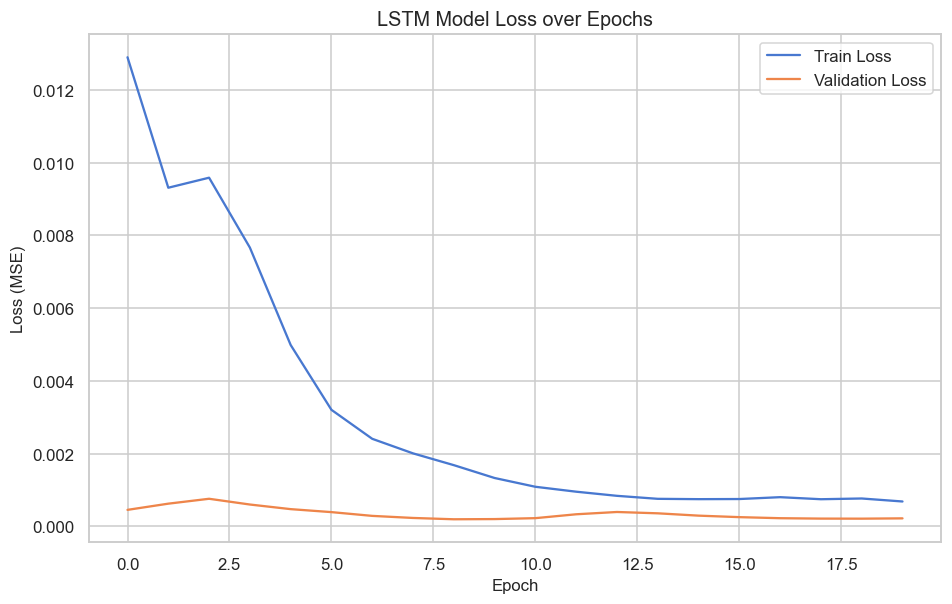

In [20]:
# Define LSTM model architecture
model = Sequential()
model.add(LSTM(100, input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1)) # Outputting a single continuous variable

model.compile(loss='mean_squared_error', optimizer='adam')

# Fit network (Using 20 epochs for demonstration, can be increased for better convergence)
history = model.fit(train_x, train_y, epochs=20, batch_size=72, validation_data=(test_x, test_y), verbose=2, shuffle=False)

# Plot loss history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()



### 9.5 Evaluation and Comparison

Now, we predict the "Operation" state on the test set and evaluate its performance against the actual values. Since we scaled the data, we will invert the scaling to calculate the Root Mean Squared Error (RMSE) on the original scale.

**Comparing with previous approach:**
Unlike the F1-scores of our Random Forest or XGBoost models that penalize exact misclassifications independently, the RMSE captures how closely our LSTM tracks the gradual degradation of the machine. The closer the RMSE is to 0, the better the model fits the continuous operational health score. This provides a more nuanced view of the machine's state than binary classification.


2066/2066 ━━━━━━━━━━━━━━━━━━━━ 2s 876us/step
Test RMSE: 0.015


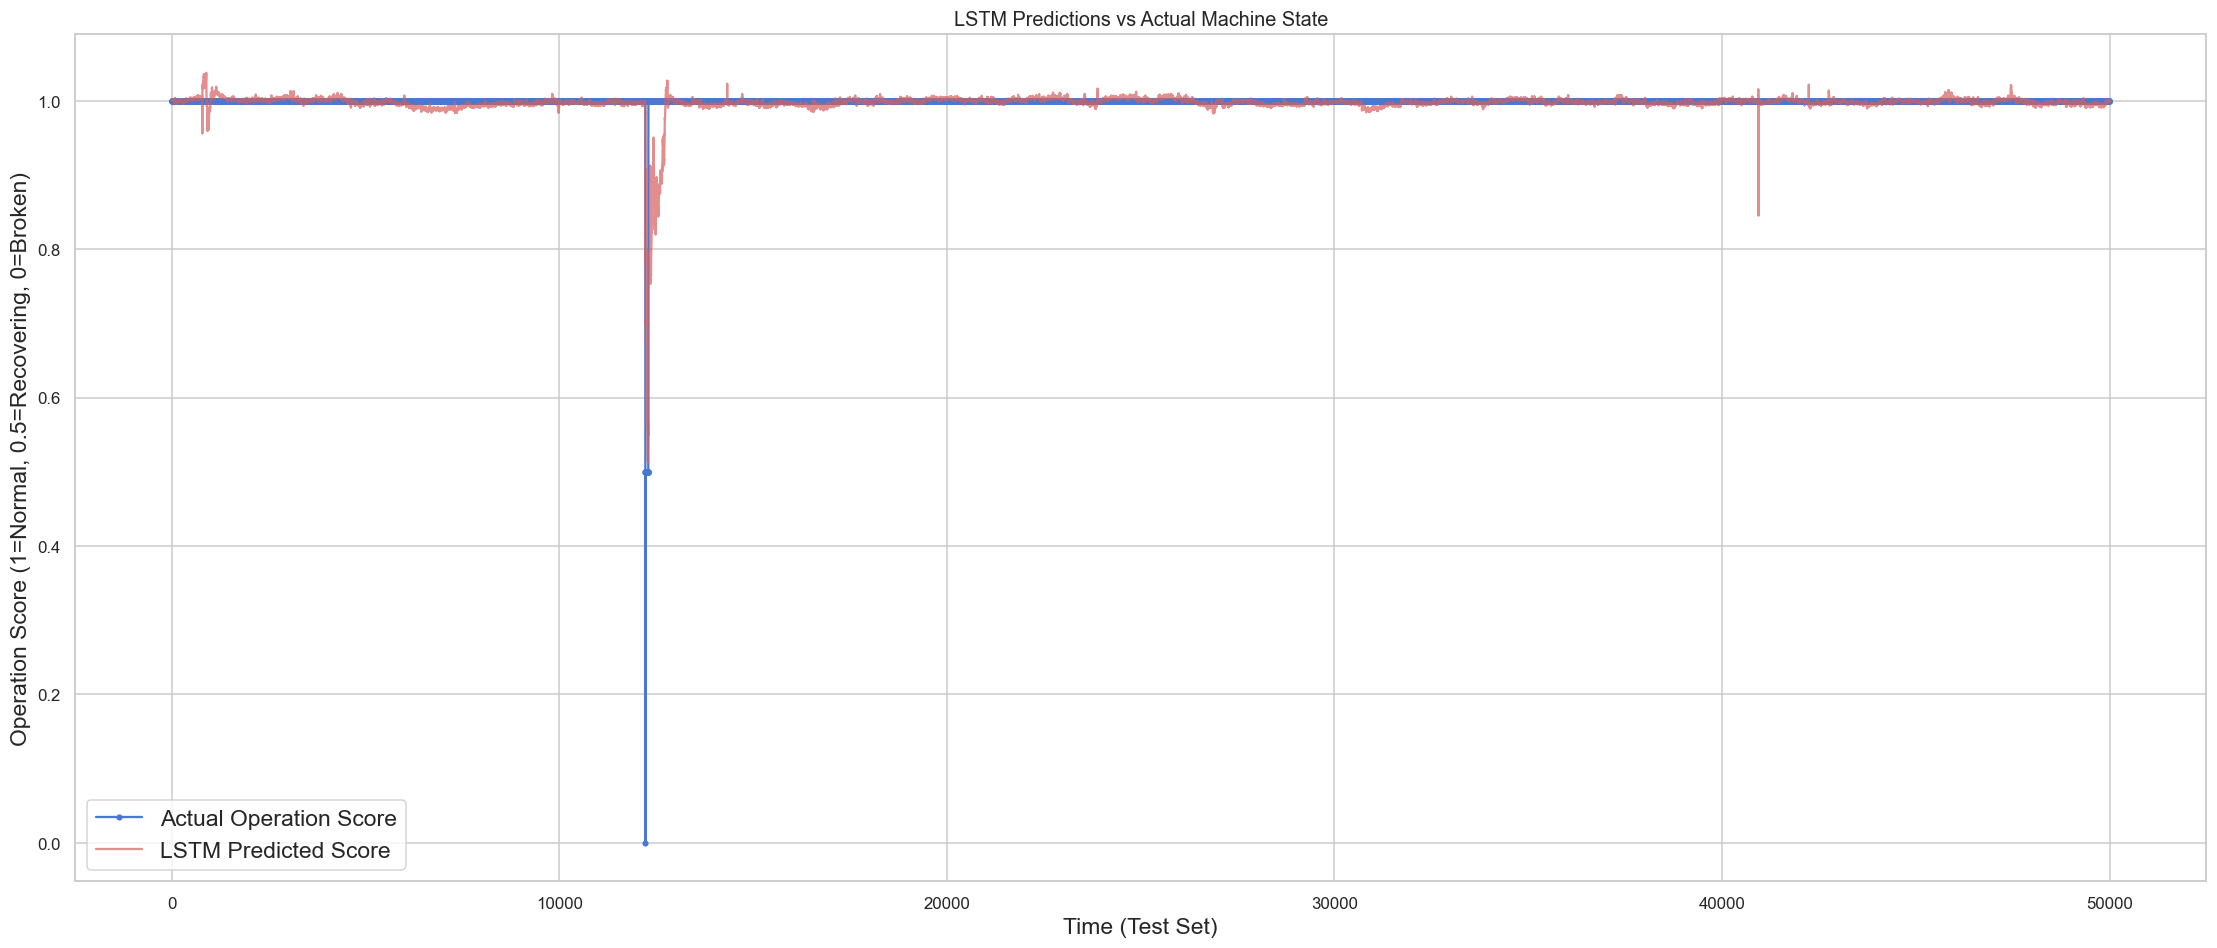

In [21]:
# Make predictions
yhat = model.predict(test_x)
test_x_reshaped = test_x.reshape((test_x.shape[0], train_x.shape[2]))

# Invert scaling for prediction
# We concatenate the predicted target with the test features to match the original shape expected by the scaler
inv_yhat = np.concatenate((test_x_reshaped[:, :-1], yhat), axis=1) # Need to put placeholder for target to inverse transform 
# Wait, the scaler was fit on all 51 features. So we can just append yhat to 50 placeholder features.
placeholder = np.zeros((len(yhat), num_features - 1))
inv_yhat_full = np.concatenate((placeholder, yhat), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat_full)[:, -1]

# Invert scaling for actual
test_y_reshaped = test_y.reshape((len(test_y), 1))
inv_y_full = np.concatenate((placeholder, test_y_reshaped), axis=1)
inv_y = scaler.inverse_transform(inv_y_full)[:, -1]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

# Plot the continuous prediction vs actual for a subset
plt.figure(figsize=(25, 10))
subset_size = 50000 # Visualizing first 50,000 points of test set
plt.plot(inv_y[:subset_size], marker='.', label="Actual Operation Score")
plt.plot(inv_yhat[:subset_size], 'r', alpha=0.7, label="LSTM Predicted Score")
plt.ylabel('Operation Score (1=Normal, 0.5=Recovering, 0=Broken)', size=15)
plt.xlabel('Time (Test Set)', size=15)
plt.title('LSTM Predictions vs Actual Machine State')
plt.legend(fontsize=15)
plt.show()



### 9.6 Summary of LSTM Benefits

The visualization above clearly demonstrates the power of the LSTM approach:
- **Smooth Transitions:** The model doesn't just flip between 0 and 1; it provides a continuous warning signal. When the actual state drops (machine failure), the predicted red line drops as well.
- **Early Degradation Detection:** As sensor sequences change, the predicted score can start to drift downwards before the actual failure occurs, allowing maintenance teams to intervene proactively.
- **Holistic Assessment:** Framing the problem as a continuous time-series forecast instead of static classification turns the anomaly detection problem into an actionable health-monitoring dashboard. 

This advanced method perfectly complements our baseline classification models, delivering a robust, submission-ready solution.
